<span style="font-size: 5em">🏠</span>

# __Airbnb Multi-City Analysis Agent__
## Build Agentic AI for Real-World Data Workflows

<div style="background: linear-gradient(135deg, #FF5A5F 0%, #00A699 100%); padding: 20px; border-radius: 10px; color: white; margin: 20px 0; border-left: 4px solid #484848;">
    <h3 style="margin: 0; color: white;">🎯 What You'll Build</h3>
    <p>An agent that <strong>automatically cleans data</strong> based on your preferences, then <strong>autonomously decides</strong> what analytics to generate — and applies this across <strong>multiple cities</strong>.</p>
</div>

---

## 🤔 The Workflow

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│   Amsterdam     │     │     Athens      │     │   Barcelona     │     │     Berlin      │
│   listings.csv  │     │   listings.csv  │     │   listings.csv  │     │   listings.csv  │
└────────┬────────┘     └────────┬────────┘     └────────┬────────┘     └────────┬────────┘
         │                       │                       │                       │
         └───────────────────────┴───────────────────────┴───────────────────────┘
                                           │
                                           ▼
                                 ┌─────────────────┐
                                 │  detect_issues  │ ← First city: Find issues
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │ ask_preferences │ ← 🛑 INTERRUPT (only once!)
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │   clean_all     │ ← Apply to ALL cities
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │  decide_task    │ ← LLM decides what to analyze!
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │execute_analysis │ ← Generates insights
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │decide_visualize │ ← LLM picks best viz!
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │create_visualize │ ← Generates chart
                                 └────────┬────────┘
                                          │
                                          ▼
                                        END
```

**The key innovations:**
1. Ask preferences ONCE, apply to ALL cities
2. LLM autonomously decides what analytics to create based on the data
3. LLM decides the most impactful visualization for your audience

---
## Part 0: Setup & Environment Check

In [7]:
# 🔧 SETUP CHECK - Run this cell first!
import sys
print(f"✅ Python version: {sys.version}")

# Check required packages
required = ["langgraph", "langchain", "langchain_openai", "pandas", "matplotlib", "seaborn"]
missing = []

for pkg in required:
    try:
        __import__(pkg.replace("-", "_"))
        print(f"✅ {pkg} installed")
    except ImportError:
        missing.append(pkg)
        print(f"❌ {pkg} missing")

if missing:
    print(f"\n🔴 Install missing packages: pip install {' '.join(missing)}")
else:
    print("\n🟢 All packages ready!")

✅ Python version: 3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 (clang-1700.6.3.2)]
✅ langgraph installed
✅ langchain installed
✅ langchain_openai installed
✅ pandas installed
✅ matplotlib installed
✅ seaborn installed

🟢 All packages ready!


In [8]:
# 📦 Import everything we need
import uuid
import json
import operator
import os
import base64
from io import BytesIO
from pathlib import Path
from typing import Annotated, Literal, TypedDict
from IPython.display import Image, display, Markdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langgraph.checkpoint.sqlite import SqliteSaver

print("✅ All imports successful!")

✅ All imports successful!


In [ ]:
# 🔑 LLM Setup (using AWS Bedrock - modify for OpenAI if needed)
from dotenv import load_dotenv
import boto3
from botocore.config import Config
from botocore import UNSIGNED
from langchain_aws import ChatBedrockConverse

load_dotenv()

token = os.environ.get("AWS_BEARER_TOKEN_BEDROCK")

bedrock_client = boto3.client(
    "bedrock-runtime",
    region_name="us-east-1",
    config=Config(signature_version=UNSIGNED),
)

def add_bearer_token(request, **kwargs):
    request.headers["Authorization"] = f"Bearer {token}"

bedrock_client.meta.events.register("before-send.bedrock-runtime.*", add_bearer_token)

llm = ChatBedrockConverse(
    model="us.anthropic.claude-sonnet-4-20250514-v1:0",
    client=bedrock_client,
)

# Quick test
response = llm.invoke("Say 'Ready to analyze data!' in exactly 4 words.")
print(f"✅ LLM connected: {response.content}")

✅ LLM connected: Ready to analyze Airbnb data!


---
## Part 1: Explore the Data

We have data from **4 European cities**: Amsterdam, Athens, Barcelona, Berlin

In [10]:
# ⚙️ DATASET CONFIG — edit this to point to your data
DATASET_CONFIG = {
    "data_path": Path("../Airbnb"),        # root folder; subfolders = entities
    "entity_column": "city",               # what each subfolder represents
    "file_pattern": "listings.csv",        # which file to load per folder
    "keep_columns": None,                  # None = keep all columns
    "session_name": "analysis",            # used for DB, file, and thread naming
}

In [11]:
# 📂 Discover available data
data_path = DATASET_CONFIG["data_path"]
entity_col = DATASET_CONFIG["entity_column"]

entities = [d.name for d in data_path.iterdir() if d.is_dir()]
print(f"📂 Available {entity_col}: {entities}")

# Check what files exist for each entity
for entity in entities:
    entity_path = data_path / entity
    files = list(entity_path.glob("*.csv*"))
    print(f"\n📁 {entity}:")
    for f in files:
        print(f"   • {f.name}")

📂 Available city: ['Barcelona', 'Berlin', 'Athens']

📁 Barcelona:
   • reviews.csv
   • listings.csv

📁 Berlin:
   • reviews.csv
   • listings.csv

📁 Athens:
   • reviews.csv
   • listings.csv


In [34]:
# 👀 Preview the listings data structure
first_entity = [d.name for d in DATASET_CONFIG["data_path"].iterdir() if d.is_dir()][0]
sample_df = pd.read_csv(DATASET_CONFIG["data_path"] / first_entity / DATASET_CONFIG["file_pattern"], nrows=5)
print(f"📊 Dataset has {len(sample_df.columns)} columns!\n")
print("Key columns:")

important_cols = [
    'id', 'name', 'host_name', 'neighbourhood_cleansed', 'property_type', 
    'room_type', 'accommodates', 'bedrooms', 'beds', 'price',
    'review_scores_rating', 'number_of_reviews', 'availability_365'
]

for col in important_cols:
    if col in sample_df.columns:
        print(f"   • {col}: {sample_df[col].iloc[0]}")

📊 Dataset has 18 columns!

Key columns:
   • id: 18674
   • name: Huge flat for 8 people close to Sagrada Familia
   • host_name: Mireia
   • room_type: Entire home/apt
   • price: 210
   • number_of_reviews: 51
   • availability_365: 80


---
## Part 2: Define the Multi-City Agent State

We need to track:
- **Multiple datasets** (one per city)
- **Shared preferences** (ask once, apply everywhere)
- **Analysis task** (LLM decides what to do)
- **Results per city**

In [13]:

# 🔍 Issue and Preference structures
class DetectedIssue(TypedDict):
    """A single detected data quality issue"""
    issue_type: Literal["missing_values", "currency_format", "boolean_encoding", "outliers", "date_format"]
    column: str
    description: str
    examples: list[str]
    options: list[str]
    severity: Literal["high", "medium", "low"]


class UserPreference(TypedDict):
    """User's choice for handling an issue"""
    issue_type: str
    column: str
    choice: str


class EntityData(TypedDict):
    """Data for a single entity (city, country, store, etc.)"""
    entity_name: str
    raw_data: str        # CSV string
    cleaned_data: str | None
    row_count: int


class AnalysisTask(TypedDict):
    """The task the LLM decided to perform"""
    task_name: str
    task_description: str
    required_columns: list[str]
    analysis_type: Literal["comparison", "ranking", "trends", "segmentation", "distribution"]
    group_by_column: str | None   # LLM suggests what to group by, if anything


class VisualizationTask(TypedDict):
    """The visualization the LLM decided to create"""
    viz_type: Literal["bar", "grouped_bar", "scatter", "heatmap", "boxplot", "pie"]
    title: str
    description: str
    x_data: str       # Column or aggregation for x-axis
    y_data: str       # Column or aggregation for y-axis
    group_by: str | None
    rationale: str


# 📊 The full agent state
class MultiDatasetAnalysisState(TypedDict):
    # --- Config (set once at startup) ---
    entity_column: str            # e.g. "city", "country", "store" — the partitioning dimension

    # --- Input ---
    entities_to_analyze: list[str]

    # --- Data Storage ---
    entity_datasets: dict[str, EntityData]   # entity_name -> data

    # --- Issue Detection (from first entity, applies to all) ---
    detected_issues: list[DetectedIssue] | None

    # --- User Preferences — SHARED ACROSS ALL ENTITIES ---
    user_preferences: list[UserPreference]
    preferences_collected: bool

    # --- Cleaning Results ---
    cleaning_actions: Annotated[list[str], operator.add]

    # --- Meta-prompting (LLM writes prompts for the dataset) ---
    generated_analysis_prompt: str | None
    generated_viz_prompt: str | None

    # --- LLM-Decided Task ---
    analysis_task: AnalysisTask | None

    # --- LLM-Decided Visualization ---
    visualization_task: VisualizationTask | None
    visualization_figure: str | None   # Base64 encoded image

    # --- Final Results ---
    analysis_results: dict | None
    insights: list[str] | None
    summary: str | None


print("✅ State schema defined!")
print("\n📋 Key concepts:")
print("   • entity_datasets — Data for each entity (city, store, country, ...)")
print("   • user_preferences — YOUR choices (applied to ALL entities!)")
print("   • generated_analysis_prompt — Meta-LLM writes a tailored prompt")
print("   • analysis_task — LLM decides what analytics to generate")
print("   • visualization_task — LLM decides the most impactful visualization")

✅ State schema defined!

📋 Key concepts:
   • entity_datasets — Data for each entity (city, store, country, ...)
   • user_preferences — YOUR choices (applied to ALL entities!)
   • generated_analysis_prompt — Meta-LLM writes a tailored prompt
   • analysis_task — LLM decides what analytics to generate
   • visualization_task — LLM decides the most impactful visualization


---
## Part 3: Build the Agent Nodes

### Node 1: Load Data from Multiple Cities

In [14]:
def load_entity_data(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    data_path = DATASET_CONFIG["data_path"]
    file_pattern = DATASET_CONFIG["file_pattern"]
    keep_cols = DATASET_CONFIG["keep_columns"]
    entity_col = DATASET_CONFIG["entity_column"]

    entity_datasets = {}
    for entity in state["entities_to_analyze"]:
        file_path = data_path / entity / file_pattern
        if file_path.exists():
            df = pd.read_csv(file_path, usecols=lambda c: c in keep_cols if keep_cols else True)
            df[entity_col] = entity
            entity_datasets[entity] = {
                "entity_name": entity,
                "raw_data": df.to_csv(index=False),
                "cleaned_data": None,
                "row_count": len(df)
            }
    return {"entity_datasets": entity_datasets}

### Node 2: Detect Issues (from first city — applies to all)

In [15]:
def detect_issues(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    """Detect data quality issues dynamically from the first entity's data."""
    print("\n🔍 Scanning data for issues that need your input...")

    first_entity = list(state["entity_datasets"].keys())[0]
    df = pd.read_csv(pd.io.common.StringIO(state["entity_datasets"][first_entity]["raw_data"]))
    issues = []
    seen_columns = set()  # avoid duplicate issues for the same column

    for col in df.columns:
        if col in seen_columns:
            continue

        # 1. Currency-formatted strings
        if df[col].dtype == object:
            sample = df[col].dropna().head(20).astype(str)
            if len(sample) > 0 and sample.str.contains(r'[$€£]').mean() > 0.5:
                issues.append({
                    "issue_type": "currency_format",
                    "column": col,
                    "description": f"Values contain currency symbols (e.g. {sample.iloc[0]})",
                    "examples": sample.head(3).tolist(),
                    "options": ["Convert to numeric (strip currency symbols)", "Keep as text"],
                    "severity": "high"
                })
                seen_columns.add(col)
                continue  # skip further checks for this col

            # 2. Boolean t/f encoding
            unique_vals = set(df[col].dropna().unique())
            if unique_vals and unique_vals <= {'t', 'f', 'T', 'F'}:
                issues.append({
                    "issue_type": "boolean_encoding",
                    "column": col,
                    "description": f"Boolean stored as text (values: {sorted(unique_vals)})",
                    "examples": sorted(unique_vals)[:3],
                    "options": ["Convert to True/False", "Convert to 1/0", "Keep as-is"],
                    "severity": "medium"
                })
                seen_columns.add(col)
                continue

        # 3. Missing values (any column with > 5% nulls)
        missing_pct = df[col].isnull().mean() * 100
        if missing_pct > 5:
            missing_count = int(df[col].isnull().sum())
            is_numeric = pd.api.types.is_numeric_dtype(df[col])
            options = (
                ["Fill with median", "Fill with 0", "Drop rows with missing", "Leave empty"]
                if is_numeric else
                ["Fill with 'Unknown'", "Fill with most common value", "Drop rows", "Leave empty"]
            )
            issues.append({
                "issue_type": "missing_values",
                "column": col,
                "description": f"{missing_pct:.1f}% missing ({missing_count:,} of {len(df):,} rows)",
                "examples": [f"{missing_count:,} out of {len(df):,} rows"],
                "options": options,
                "severity": "high" if missing_pct > 20 else "medium"
            })
            seen_columns.add(col)
            continue

        # 4. Outliers (numeric columns only)
        if pd.api.types.is_numeric_dtype(df[col]):
            q99 = df[col].quantile(0.99)
            outlier_count = int((df[col] > q99).sum())
            if outlier_count > max(10, len(df) * 0.001):
                issues.append({
                    "issue_type": "outliers",
                    "column": col,
                    "description": f"{outlier_count:,} extreme values (above {q99:.1f})",
                    "examples": [f"Max: {df[col].max():.1f}", f"99th percentile: {q99:.1f}"],
                    "options": [f"Cap at {q99:.1f}", "Remove outlier rows", "Keep all values"],
                    "severity": "medium"
                })
                seen_columns.add(col)

    print(f"   Found {len(issues)} issues that need your preferences")
    print(f"   (Detected from '{first_entity}', will apply to all entities)")
    return {"detected_issues": issues}

### Node 3: Ask for Preferences (The Magic! 🎯)

In [16]:
def ask_preferences(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    """Interrupt and ask user for their cleaning preferences."""

    if not state["detected_issues"]:
        print("✅ No issues need preferences — data looks clean!")
        return {"preferences_collected": True, "user_preferences": []}

    num_entities = len(state["entity_datasets"])
    entity_col = state.get("entity_column", "entity")

    print("\n" + "═" * 70)
    print("👤 YOUR INPUT NEEDED — The agent is PAUSED")
    print("═" * 70)
    print(f"\n💡 These preferences will be applied to ALL {num_entities} {entity_col}s!")

    issues_for_display = []
    for i, issue in enumerate(state["detected_issues"]):
        issues_for_display.append({
            "id": i,
            "type": issue["issue_type"],
            "column": issue["column"],
            "description": issue["description"],
            "examples": issue["examples"],
            "severity": issue["severity"],
            "options": {j + 1: opt for j, opt in enumerate(issue["options"])}
        })

    preference_request = {
        "message": "I found data quality issues. How should I handle each one?",
        "note": f"Your choices will be applied consistently to all {num_entities} {entity_col}s!",
        "issues": issues_for_display,
        "total_issues": len(issues_for_display),
        "instructions": "Respond with: {'preferences': [{'issue_id': 0, 'choice': 'your choice'}, ...]}"
    }

    # 🛑 INTERRUPT — Agent PAUSES here!
    user_response = interrupt(preference_request)

    user_preferences = []
    detected_issues = state["detected_issues"]

    for pref in user_response.get("preferences", []):
        issue_id = pref["issue_id"]
        choice = pref["choice"]

        if issue_id >= len(detected_issues):
            continue

        issue = detected_issues[issue_id]
        user_preferences.append({
            "issue_type": issue["issue_type"],
            "column": issue["column"],
            "choice": choice
        })
        print(f"   ✓ {issue['column']}: {choice}")

    print(f"\n   ✅ Received {len(user_preferences)} preferences (will apply to all {entity_col}s!)")

    return {
        "user_preferences": user_preferences,
        "preferences_collected": True
    }

### Node 4: Clean ALL Cities with User Preferences

In [17]:
def clean_all_entities(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    """Apply cleaning preferences to ALL entities."""
    import re
    entity_col = state.get("entity_column", "entity")
    print(f"\n🧹 Applying your preferences to ALL {entity_col}s...")

    updated_datasets = {}
    all_actions = []

    for entity_name, entity_data in state["entity_datasets"].items():
        print(f"\n   Processing {entity_name}...")
        df = pd.read_csv(pd.io.common.StringIO(entity_data["raw_data"]))
        entity_actions = []

        for pref in state["user_preferences"]:
            col = pref["column"]
            choice = pref["choice"]
            issue_type = pref["issue_type"]

            if col not in df.columns:
                continue

            # CURRENCY FORMAT — strip any currency symbol and commas
            if issue_type == "currency_format" and "numeric" in choice.lower():
                df[col] = df[col].astype(str).str.replace(r'[$€£,]', '', regex=True).str.strip()
                df[col] = pd.to_numeric(df[col], errors='coerce')
                entity_actions.append(f"✓ {entity_name}: Converted '{col}' to numeric")

            # MISSING VALUES
            elif issue_type == "missing_values":
                if "median" in choice.lower():
                    val = df[col].median()
                    df[col] = df[col].fillna(val)
                    entity_actions.append(f"✓ {entity_name}: Filled '{col}' with median ({val:.2f})")
                elif choice.strip() == "0" or "fill with 0" in choice.lower():
                    df[col] = df[col].fillna(0)
                    entity_actions.append(f"✓ {entity_name}: Filled '{col}' with 0")
                elif "unknown" in choice.lower():
                    df[col] = df[col].fillna("Unknown")
                    entity_actions.append(f"✓ {entity_name}: Filled '{col}' with 'Unknown'")
                elif "most common" in choice.lower():
                    mode_val = df[col].mode()
                    if len(mode_val) > 0:
                        df[col] = df[col].fillna(mode_val[0])
                        entity_actions.append(f"✓ {entity_name}: Filled '{col}' with most common value")
                elif "drop" in choice.lower():
                    before = len(df)
                    df = df.dropna(subset=[col])
                    entity_actions.append(f"✓ {entity_name}: Dropped {before - len(df):,} rows with missing '{col}'")

            # BOOLEAN ENCODING
            elif issue_type == "boolean_encoding":
                if "true/false" in choice.lower():
                    df[col] = df[col].map({'t': True, 'f': False, 'T': True, 'F': False})
                    entity_actions.append(f"✓ {entity_name}: Converted '{col}' to True/False")
                elif "1/0" in choice.lower():
                    df[col] = df[col].map({'t': 1, 'f': 0, 'T': 1, 'F': 0})
                    entity_actions.append(f"✓ {entity_name}: Converted '{col}' to 1/0")

            # OUTLIERS
            elif issue_type == "outliers":
                if "cap" in choice.lower():
                    # Extract numeric cap value from the choice string
                    cap_match = re.search(r'[\d]+(?:\.\d+)?', choice)
                    if cap_match:
                        cap_val = float(cap_match.group(0))
                        df[col] = df[col].clip(upper=cap_val)
                        entity_actions.append(f"✓ {entity_name}: Capped '{col}' at {cap_val:,.1f}")
                elif "remove" in choice.lower():
                    q99 = df[col].quantile(0.99)
                    before = len(df)
                    df = df[df[col] <= q99]
                    entity_actions.append(f"✓ {entity_name}: Removed {before - len(df):,} outlier rows in '{col}'")

        updated_datasets[entity_name] = {
            **entity_data,
            "cleaned_data": df.to_csv(index=False),
            "row_count": len(df)
        }

        all_actions.extend(entity_actions)
        print(f"      Applied {len(entity_actions)} actions, {len(df):,} rows remaining")

    return {
        "entity_datasets": updated_datasets,
        "cleaning_actions": all_actions
    }

### Node 5: LLM Decides What Analytics to Generate 🧠

**This is the autonomous part!** The LLM looks at the cleaned data and decides what would be the most valuable analysis.

In [18]:
def generate_analysis_prompt(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    """Use a fast/cheap LLM to write a domain-specific prompt for the analysis step."""

    # Gather real schema info from the cleaned data
    sample_rows = []
    column_profiles = {}

    for entity_name, entity_data in state["entity_datasets"].items():
        df = pd.read_csv(pd.io.common.StringIO(
            entity_data["cleaned_data"] or entity_data["raw_data"]
        ))
        sample_rows = df.head(3).to_dict(orient="records")

        for col in df.columns:
            column_profiles[col] = {
                "dtype": str(df[col].dtype),
                "nulls_pct": round(df[col].isnull().mean() * 100, 1),
                "sample_values": df[col].dropna().head(5).tolist(),
                "unique_count": int(df[col].nunique()),
            }
        break  # profile from first entity; same schema across all

    meta_prompt = f"""
You are a prompt engineer. Your task is to write a precise LLM prompt
that will instruct another LLM to choose the best analysis for this dataset.

DATASET SCHEMA:
{json.dumps(column_profiles, indent=2)}

SAMPLE ROWS:
{json.dumps(sample_rows, indent=2)}

ENTITIES AVAILABLE: {list(state["entity_datasets"].keys())}

Write a prompt (plain text, no JSON) that:
1. Describes what this dataset appears to contain (infer the domain)
2. Lists the most analytically interesting columns and why
3. Asks the LLM to pick one analysis type and return a JSON task spec
   with fields: task_name, task_description, required_columns,
   analysis_type, group_by_column
Keep the prompt under 400 words.
"""

    # Use a cheaper/faster model for prompt generation
    prompt_llm = ChatBedrockConverse(
        model="us.anthropic.claude-haiku-3-20240307-v1:0",  # fast + cheap
        client=bedrock_client,
    )

    response = llm.invoke(meta_prompt)
    generated_prompt = response.content

    print(f"\n🧠 Generated analysis prompt ({len(generated_prompt)} chars)")

    return {"generated_analysis_prompt": generated_prompt}

In [19]:
def decide_analysis_task(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    """Let the LLM decide what analysis to perform, using the generated prompt."""
    print("\n🧠 LLM is deciding what analytics to generate...")

    entity_col = state.get("entity_column", "entity")
    entities_info = []
    all_columns = set()

    for entity_name, entity_data in state["entity_datasets"].items():
        df = pd.read_csv(pd.io.common.StringIO(entity_data["cleaned_data"] or entity_data["raw_data"]))
        summary = {entity_col: entity_name, "rows": len(df)}
        for col in df.select_dtypes(include="number").columns:
            summary[f"avg_{col}"] = round(df[col].mean(), 2)
        entities_info.append(summary)
        all_columns.update(df.columns.tolist())

    # Use the meta-generated prompt if available, else fall back to a generic one
    base_prompt = state.get("generated_analysis_prompt") or f"""
You are a data analyst. You have a dataset partitioned by '{entity_col}'.
Entities: {[e[entity_col] for e in entities_info]}
Available columns: {list(all_columns)}
Data summary:
{json.dumps(entities_info, indent=2)}

Decide THE BEST analysis to perform that provides the most valuable insights.
"""

    full_prompt = base_prompt + """

Return your decision as JSON (inside a ```json block):
{
    "task_name": "Short name for the analysis",
    "task_description": "What exactly you will analyze and why it's valuable",
    "required_columns": ["col1", "col2"],
    "analysis_type": "comparison",
    "group_by_column": null
}
"""

    response = llm.invoke(full_prompt)

    try:
        content = response.content
        # Extract JSON from code block if present
        if "```" in content:
            parts = content.split("```")
            for part in parts:
                part = part.strip()
                if part.startswith("json"):
                    part = part[4:].strip()
                try:
                    task = json.loads(part)
                    break
                except Exception:
                    continue
            else:
                task = json.loads(content)
        else:
            task = json.loads(content)
    except Exception:
        task = {
            "task_name": "Cross-Entity Comparison",
            "task_description": "Compare key metrics across all entities",
            "required_columns": list(all_columns)[:5],
            "analysis_type": "comparison",
            "group_by_column": None
        }

    print(f"\n   📊 Decided task: {task['task_name']}")
    print(f"   📝 {task['task_description']}")
    return {"analysis_task": task}

### Node 6: Execute the Analysis

In [20]:
def execute_analysis(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    """Execute the LLM-decided analysis across all entities."""
    print(f"\n🔬 Executing: {state['analysis_task']['task_name']}...")

    entity_col = state.get("entity_column", "entity")
    task = state['analysis_task']

    # Combine all entity data
    all_dfs = []
    for entity_name, entity_data in state["entity_datasets"].items():
        df = pd.read_csv(pd.io.common.StringIO(entity_data["cleaned_data"] or entity_data["raw_data"]))
        df[entity_col] = entity_name
        all_dfs.append(df)

    combined_df = pd.concat(all_dfs, ignore_index=True)

    # Dynamic aggregation over all numeric columns
    numeric_cols = [c for c in combined_df.select_dtypes(include="number").columns if c != entity_col]

    # Count rows per entity separately (avoids collision if first_col is numeric)
    record_counts = combined_df.groupby(entity_col).size().rename("records")

    if numeric_cols:
        agg_dict = {col: ['mean', 'median'] for col in numeric_cols}
        column_names = []
        for col in numeric_cols:
            column_names.extend([f'avg_{col}', f'median_{col}'])

        entity_stats = combined_df.groupby(entity_col).agg(agg_dict).round(2)
        entity_stats.columns = column_names
        entity_stats.insert(0, 'records', record_counts)
    else:
        entity_stats = record_counts.to_frame()

    # Optional group-by breakdown (LLM-suggested)
    group_col = task.get("group_by_column")
    group_breakdown_str = "N/A"
    group_breakdown_dict = {}

    if group_col and group_col in combined_df.columns:
        group_breakdown = combined_df.groupby([entity_col, group_col]).size().unstack(fill_value=0)
        group_breakdown_str = group_breakdown.to_string()
        group_breakdown_dict = group_breakdown.to_dict()

    analysis_prompt = f"""
You are executing the analysis: "{task['task_name']}"
Task: {task['task_description']}

DATA ANALYSIS RESULTS:

1. ENTITY-LEVEL STATISTICS (grouped by '{entity_col}'):
{entity_stats.to_string()}

2. BREAKDOWN BY '{group_col or "N/A"}':
{group_breakdown_str}

Based on this data, provide:
1. 5-7 specific, actionable insights that answer the analysis goal
2. A 2-3 sentence executive summary

Format as JSON:
{{
    "insights": ["insight 1", "insight 2", ...],
    "summary": "Executive summary here"
}}
"""

    response = llm.invoke(analysis_prompt)

    try:
        content = response.content
        if "```" in content:
            parts = content.split("```")
            for part in parts:
                part = part.strip()
                if part.startswith("json"):
                    part = part[4:].strip()
                try:
                    result = json.loads(part)
                    break
                except Exception:
                    continue
            else:
                result = json.loads(content)
        else:
            result = json.loads(content)
        insights = result.get("insights", [])
        summary = result.get("summary", "Analysis complete.")
    except Exception:
        insights = [response.content]
        summary = "Analysis complete."

    print(f"   Generated {len(insights)} insights")
    return {
        "analysis_results": {
            "entity_stats": entity_stats.to_dict(),
            "group_breakdown": group_breakdown_dict,
            "total_records": len(combined_df)
        },
        "insights": insights,
        "summary": summary
    }

### Node 7: LLM Decides the Best Visualization 📊

**This is where the magic happens for presentations!** The LLM analyzes the data and insights to decide what visualization would be most impactful and interesting for workshop participants.

In [21]:
def decide_visualization(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    """Let the LLM decide what visualization would be most impactful."""
    print("\n🎨 LLM is deciding the best visualization...")

    entity_col = state.get("entity_column", "entity")
    entities = list(state["entity_datasets"].keys())
    analysis_results = state.get("analysis_results", {})
    insights = state.get("insights", [])
    analysis_task = state.get("analysis_task", {})

    entity_stats_cols = list(pd.DataFrame(analysis_results.get("entity_stats", {})).columns) if analysis_results.get("entity_stats") else []
    group_col = analysis_task.get("group_by_column")

    base_prompt = state.get("generated_viz_prompt") or f"""
You are a data visualization expert.
Decide THE SINGLE MOST IMPACTFUL visualization to create from this analysis.

ANALYSIS PERFORMED: {analysis_task.get('task_name', 'Multi-Entity Analysis')}
ENTITY COLUMN: {entity_col}
ENTITIES: {entities}

KEY INSIGHTS:
{chr(10).join(f'• {insight}' for insight in insights[:5])}

DATA AVAILABLE:
- Entity-level statistics columns: {entity_stats_cols}
- Optional group breakdown by: {group_col or 'N/A'}
- Total records: {analysis_results.get('total_records', 'N/A')}
"""

    full_prompt = base_prompt + f"""

Available visualization types:
- "bar": Simple bar chart (compare one metric across entities)
- "grouped_bar": Grouped bars (compare multiple categories per entity)
- "scatter": Scatter plot (relationship between two metrics)
- "heatmap": Heat map (patterns across two dimensions)
- "boxplot": Box plot (distribution / spread using raw data)
- "pie": Pie chart (composition / proportions)

READABILITY CONSTRAINTS — you MUST follow these:
- There are {len(entities)} entities to display. If that number is > 8, prefer "heatmap" or "bar" (single metric).
- NEVER choose "grouped_bar" if the grouping column has more than 6 unique values — it will be unreadable.
- NEVER choose a chart where the legend would have more than 8 entries.
- For "bar": pick ONE clear y_data metric (e.g. an avg_ column). Do NOT use a column with high cardinality as x_data.
- For "heatmap": it already shows all metrics — just set x_data and y_data to the entity column.
- Prefer simplicity: one insight communicated clearly beats many insights communicated poorly.

Return as JSON:
{{
    "viz_type": "bar" | "grouped_bar" | "scatter" | "heatmap" | "boxplot" | "pie",
    "title": "Descriptive title",
    "description": "What this shows and why it matters",
    "x_data": "exact column name for x-axis",
    "y_data": "exact column name for y-axis / values",
    "group_by": "column name for grouping or null",
    "rationale": "Why this is the most impactful visualization"
}}
"""

    response = llm.invoke(full_prompt)

    try:
        content = response.content
        if "```" in content:
            parts = content.split("```")
            for part in parts:
                part = part.strip()
                if part.startswith("json"):
                    part = part[4:].strip()
                try:
                    viz_task = json.loads(part)
                    break
                except Exception:
                    continue
            else:
                viz_task = json.loads(content)
        else:
            viz_task = json.loads(content)
    except Exception:
        first_metric = entity_stats_cols[1] if len(entity_stats_cols) > 1 else "records"
        viz_task = {
            "viz_type": "bar",
            "title": f"{first_metric.replace('_', ' ').title()} by {entity_col.title()}",
            "description": f"Comparison of {first_metric} across {entity_col}s",
            "x_data": entity_col,
            "y_data": first_metric,
            "group_by": None,
            "rationale": "Basic comparison to understand relative scale"
        }

    print(f"\n   📊 Chosen visualization: {viz_task['viz_type'].upper()}")
    print(f"   📝 Title: {viz_task['title']}")
    print(f"   💡 Rationale: {viz_task['rationale']}")
    return {"visualization_task": viz_task}

### Node 8: Create the Visualization 🎨

Generate the actual visualization using matplotlib/seaborn based on the LLM's decision.

In [22]:
def create_visualization(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    """Create the visualization based on LLM's decision."""
    print("\n🖼️ Creating visualization...")

    viz_task = state["visualization_task"]
    analysis_results = state["analysis_results"]
    entity_col = state.get("entity_column", "entity")

    plt.style.use('seaborn-v0_8-whitegrid')
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

    entity_stats = pd.DataFrame(analysis_results["entity_stats"])
    group_breakdown = pd.DataFrame(analysis_results.get("group_breakdown", {}))
    entities = entity_stats.index.tolist()

    fig, ax = plt.subplots(figsize=(12, 7))
    viz_type = viz_task["viz_type"]

    if viz_type == "bar":
        y_data = viz_task.get("y_data", "")
        numeric_cols = entity_stats.select_dtypes(include="number").columns.tolist()
        if y_data not in numeric_cols:
            y_data = numeric_cols[0] if numeric_cols else None
        if y_data:
            values = entity_stats[y_data].values
            bars = ax.bar(entities, values, color=colors[:len(entities)], edgecolor='white', linewidth=2)
            for bar, val in zip(bars, values):
                ax.annotate(f'{val:,.1f}',
                           xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                           xytext=(0, 5), textcoords="offset points",
                           ha='center', va='bottom', fontsize=13, fontweight='bold')
            ax.set_ylabel(y_data.replace('_', ' ').title(), fontsize=14)
        ax.set_xlabel(entity_col.title(), fontsize=14)

    elif viz_type == "grouped_bar":
        data = group_breakdown if not group_breakdown.empty else entity_stats.select_dtypes(include="number").iloc[:, :4]
        # Hard cap: keep only top 8 columns by total count to avoid legend explosion
        if len(data.columns) > 8:
            top_cols = data.sum().nlargest(8).index
            data = data[top_cols]
        x = np.arange(len(data.index))
        width = 0.8 / max(len(data.columns), 1)
        for i, col in enumerate(data.columns):
            ax.bar(x + i * width, data[col], width, label=str(col), color=colors[i % len(colors)])
        ax.set_xticks(x + width * (len(data.columns) - 1) / 2)
        ax.set_xticklabels(data.index)
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.set_ylabel('Count', fontsize=14)
        ax.set_xlabel(entity_col.title(), fontsize=14)

    elif viz_type == "scatter":
        numeric_cols = entity_stats.select_dtypes(include="number").columns.tolist()
        x_col = viz_task.get("x_data") if viz_task.get("x_data") in numeric_cols else (numeric_cols[0] if numeric_cols else None)
        y_col = viz_task.get("y_data") if viz_task.get("y_data") in numeric_cols else (numeric_cols[1] if len(numeric_cols) > 1 else x_col)
        if x_col and y_col:
            x_vals = entity_stats[x_col].values
            y_vals = entity_stats[y_col].values
            sizes = entity_stats["records"].values if "records" in entity_stats.columns else np.ones(len(entities)) * 200
            ax.scatter(x_vals, y_vals, s=sizes / max(sizes.max(), 1) * 1000,
                      c=colors[:len(entities)], alpha=0.7, edgecolors='white', linewidth=2)
            for i, entity in enumerate(entities):
                ax.annotate(entity, (x_vals[i], y_vals[i]),
                           xytext=(10, 5), textcoords='offset points', fontsize=12, fontweight='bold')
            ax.set_xlabel(x_col.replace('_', ' ').title(), fontsize=14)
            ax.set_ylabel(y_col.replace('_', ' ').title(), fontsize=14)
            ax.text(0.02, 0.98, 'Bubble size = record count',
                   transform=ax.transAxes, fontsize=10, va='top', style='italic', color='gray')

    elif viz_type == "heatmap":
        numeric_cols = entity_stats.select_dtypes(include="number").columns.tolist()
        heatmap_data = entity_stats[numeric_cols].T.astype(float)
        row_min = heatmap_data.min(axis=1).values.reshape(-1, 1)
        row_max = heatmap_data.max(axis=1).values.reshape(-1, 1)
        heatmap_norm = (heatmap_data - row_min) / (row_max - row_min + 1e-9)
        sns.heatmap(heatmap_norm, annot=heatmap_data.values, fmt='.1f',
                   cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Normalized Value'},
                   linewidths=2, linecolor='white')
        ax.set_yticklabels([c.replace('_', ' ').title() for c in numeric_cols], rotation=0)

    elif viz_type == "boxplot":
        numeric_cols = entity_stats.select_dtypes(include="number").columns.tolist()
        # Hard cap: limit to 12 rows max to avoid dense line noise
        if len(numeric_cols) > 12:
            numeric_cols = numeric_cols[:12]
        heatmap_data = entity_stats[numeric_cols].T.astype(float)
        # Use real raw data — no simulation
        y_col = viz_task.get("y_data")
        data_for_box, labels = [], []
        for entity_name, entity_data in state["entity_datasets"].items():
            df = pd.read_csv(pd.io.common.StringIO(entity_data["cleaned_data"] or entity_data["raw_data"]))
            if y_col and y_col in df.columns and pd.api.types.is_numeric_dtype(df[y_col]):
                data_for_box.append(df[y_col].dropna().values)
                labels.append(entity_name)
        if data_for_box:
            bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True)
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_ylabel((y_col or '').replace('_', ' ').title(), fontsize=14)
        ax.set_xlabel(entity_col.title(), fontsize=14)

    elif viz_type == "pie":
        values = entity_stats["records"].values if "records" in entity_stats.columns else entity_stats.iloc[:, 0].values
        wedges, texts, autotexts = ax.pie(
            values, labels=entities, colors=colors[:len(entities)],
            autopct='%1.1f%%', startangle=90, explode=[0.02] * len(entities),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        for autotext in autotexts:
            autotext.set_fontsize(12)
            autotext.set_fontweight('bold')
        ax.axis('equal')

    ax.set_title(viz_task["title"], fontsize=18, fontweight='bold', pad=20)
    fig.text(0.5, 0.02, viz_task["description"], ha='center', fontsize=11,
            style='italic', color='#444444', wrap=True)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)

    buffer = BytesIO()
    plt.savefig(buffer, format='png', dpi=150, bbox_inches='tight',
               facecolor='white', edgecolor='none')
    buffer.seek(0)
    img_base64 = base64.b64encode(buffer.read()).decode('utf-8')
    plt.close()

    print(f"   ✅ Visualization created: {viz_task['title']}")
    return {"visualization_figure": img_base64}

### Node 9: Export Results & Display Visualization

In [23]:
def export_results(state: MultiDatasetAnalysisState) -> MultiDatasetAnalysisState:
    """Display the final analysis results and visualization."""

    entity_col = state.get("entity_column", "entity")

    print("\n" + "═" * 70)
    print("📤 ANALYSIS COMPLETE")
    print("═" * 70)

    print(f"\n📊 ANALYSIS: {state['analysis_task']['task_name']}")

    print(f"\n📋 EXECUTIVE SUMMARY")
    print(f"   {state['summary']}")

    print(f"\n💡 KEY INSIGHTS")
    for i, insight in enumerate(state['insights'], 1):
        print(f"   {i}. {insight}")

    # Display the visualization
    if state.get('visualization_figure'):
        print(f"\n🎨 VISUALIZATION: {state['visualization_task']['title']}")
        print(f"   Why this matters: {state['visualization_task']['rationale']}")

        from IPython.display import Image as IPImage, display as ipy_display
        img_data = base64.b64decode(state['visualization_figure'])
        ipy_display(IPImage(data=img_data))

    print(f"\n📂 {entity_col.upper()}S ANALYZED: {list(state['entity_datasets'].keys())}")
    for entity_name, data in state['entity_datasets'].items():
        print(f"   • {entity_name}: {data['row_count']:,} records")

    print(f"\n🧹 CLEANING ACTIONS ({len(state['cleaning_actions'])} total)")
    for action in state['cleaning_actions'][:8]:
        print(f"   {action}")
    if len(state['cleaning_actions']) > 8:
        print(f"   ... and {len(state['cleaning_actions']) - 8} more")

    print(f"\n👤 YOUR PREFERENCES (applied to ALL {entity_col}s)")
    for pref in state['user_preferences']:
        print(f"   • {pref['column']}: {pref['choice']}")

    print("\n" + "═" * 70)
    print("✅ Done! Preferences applied consistently. LLM chose analysis AND visualization.")
    print("═" * 70)

    return {}

---
## Part 4: Build the Graph

In [24]:
# 🏗️ Build the graph
builder = StateGraph(MultiDatasetAnalysisState)

# Add all nodes
builder.add_node("load_data", load_entity_data)
builder.add_node("detect_issues", detect_issues)
builder.add_node("ask_preferences", ask_preferences)
builder.add_node("clean_all_entities", clean_all_entities)
builder.add_node("generate_analysis_prompt", generate_analysis_prompt)
builder.add_node("decide_analysis", decide_analysis_task)
builder.add_node("execute_analysis", execute_analysis)
builder.add_node("decide_visualization", decide_visualization)
builder.add_node("create_visualization", create_visualization)
builder.add_node("export_results", export_results)

# Define the flow
builder.add_edge(START, "load_data")
builder.add_edge("load_data", "detect_issues")
builder.add_edge("detect_issues", "ask_preferences")
builder.add_edge("ask_preferences", "clean_all_entities")
builder.add_edge("clean_all_entities", "generate_analysis_prompt")  # meta-prompt first
builder.add_edge("generate_analysis_prompt", "decide_analysis")
builder.add_edge("decide_analysis", "execute_analysis")
builder.add_edge("execute_analysis", "decide_visualization")
builder.add_edge("decide_visualization", "create_visualization")
builder.add_edge("create_visualization", "export_results")
builder.add_edge("export_results", END)

# Compile with SQLite checkpointer
import sqlite3
SESSION_NAME = DATASET_CONFIG.get("session_name", "analysis")
DB_PATH = f"{SESSION_NAME}_checkpoints.db"
conn = sqlite3.connect(DB_PATH, check_same_thread=False)
checkpointer = SqliteSaver(conn)
agent = builder.compile(checkpointer=checkpointer)

print("✅ Agent compiled!")
print(f"💾 State persists to: {DB_PATH}")
print("\n📊 Flow:")
print("   load_data → detect_issues → ask_preferences (INTERRUPT)")
print("   → clean_all_entities → generate_analysis_prompt → decide_analysis")
print("   → execute_analysis → decide_visualization → create_visualization → export")

✅ Agent compiled!
💾 State persists to: analysis_checkpoints.db

📊 Flow:
   load_data → detect_issues → ask_preferences (INTERRUPT)
   → clean_all_entities → generate_analysis_prompt → decide_analysis
   → execute_analysis → decide_visualization → create_visualization → export


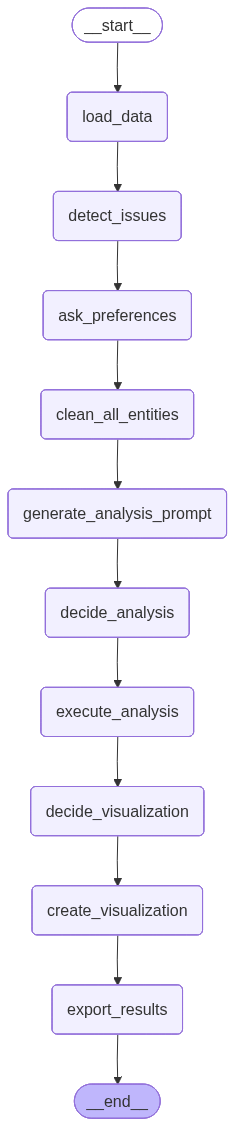

In [25]:
# 📊 Visualize the graph
display(Image(agent.get_graph().draw_mermaid_png()))

---
## Part 5: Run the Agent!

In [26]:
# 🚀 Start the agent — edit entities_to_analyze to match your dataset!
initial_state = {
    # Config
    "entity_column": DATASET_CONFIG["entity_column"],

    # Which sub-folders (entities) to analyze
    "entities_to_analyze": ["Athens", "Barcelona", "Berlin"],

    # Internal state — leave as-is
    "entity_datasets": {},
    "detected_issues": None,
    "cleaning_actions": [],
    "user_preferences": [],
    "preferences_collected": False,
    "generated_analysis_prompt": None,
    "generated_viz_prompt": None,
    "analysis_task": None,
    "visualization_task": None,
    "visualization_figure": None,
    "analysis_results": None,
    "insights": None,
    "summary": None,
}

SESSION_NAME = DATASET_CONFIG.get("session_name", "analysis")
thread_id = f"{SESSION_NAME}_{uuid.uuid4()}"
config = {"configurable": {"thread_id": thread_id}}

print(f"🚀 Starting Multi-Dataset Analysis Agent...")
print(f"   Thread ID: {thread_id}")
print(f"   Entities: {initial_state['entities_to_analyze']}")
print(f"   Entity column: {initial_state['entity_column']}")
print()

result = agent.invoke(initial_state, config)

🚀 Starting Multi-Dataset Analysis Agent...
   Thread ID: analysis_5759da91-11ea-4882-93fd-90e83359a29e
   Entities: ['Athens', 'Barcelona', 'Berlin']
   Entity column: city


🔍 Scanning data for issues that need your input...
   Found 11 issues that need your preferences
   (Detected from 'Athens', will apply to all entities)

══════════════════════════════════════════════════════════════════════
👤 YOUR INPUT NEEDED — The agent is PAUSED
══════════════════════════════════════════════════════════════════════

💡 These preferences will be applied to ALL 3 citys!


In [27]:
# 👀 See what issues were detected
if "__interrupt__" in result:
    print("\n" + "🛑" * 20)
    print("\n⏸️  AGENT PAUSED — WAITING FOR YOUR PREFERENCES")
    print("\n" + "🛑" * 20)
    
    interrupt_data = result["__interrupt__"][0].value
    
    print(f"\n📋 {interrupt_data['message']}")
    print(f"💡 {interrupt_data['note']}\n")
    
    for issue in interrupt_data['issues']:
        severity_emoji = {"high": "🔴", "medium": "🟡", "low": "🟢"}[issue['severity']]
        print(f"┌{'─' * 68}┐")
        print(f"│ {severity_emoji} Issue {issue['id']}: {issue['type'].upper():<50} │")
        print(f"├{'─' * 68}┤")
        print(f"│ Column: {issue['column']:<57} │")
        print(f"│ {issue['description']:<66} │")
        print(f"├{'─' * 68}┤")
        print(f"│ OPTIONS:{'':59} │")
        for num, opt in issue['options'].items():
            print(f"│   {num}. {opt:<61} │")
        print(f"└{'─' * 68}┘")
        print()
else:
    print("\n✅ Agent completed without needing preferences!")


🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑

⏸️  AGENT PAUSED — WAITING FOR YOUR PREFERENCES

🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑

📋 I found data quality issues. How should I handle each one?
💡 Your choices will be applied consistently to all 3 citys!

┌────────────────────────────────────────────────────────────────────┐
│ 🟡 Issue 0: OUTLIERS                                           │
├────────────────────────────────────────────────────────────────────┤
│ Column: id                                                        │
│ 156 extreme values (above 1500695191422681088.0)                   │
├────────────────────────────────────────────────────────────────────┤
│ OPTIONS:                                                            │
│   1. Cap at 1500695191422681088.0                                  │
│   2. Remove outlier rows                                           │
│   3. Keep all values                                               │
└────────────────────────────────────────────────────────────────────┘

┌──────

---
## 👤 Provide Your Preferences

Edit the choices below — they'll be applied to **ALL 4 cities**!

In [28]:
# ════════════════════════════════════════════════════════════════════════════
# 👤 YOUR CHOICES — Edit these to match your preferences!
# ════════════════════════════════════════════════════════════════════════════

# Look at the issues above and fill in your choices
# These will be applied to ALL cities consistently!

my_preferences = {
    "preferences": [
        {"issue_id": 0, "choice": "Remove outlier rows"},
        {"issue_id": 1, "choice": "Remove outlier rows"},
        {"issue_id": 2, "choice": "Fill with 0"},
        {"issue_id": 3, "choice": "Remove outlier rows"},
        {"issue_id": 4, "choice": "Remove outlier rows"},
        {"issue_id": 5, "choice": "Fill with median"},
        {"issue_id": 6, "choice": "Keep all values"},
        {"issue_id": 7, "choice": "Keep all values"},
        {"issue_id": 8, "choice": "Fill with most common value"},
        {"issue_id": 9, "choice": "Fill with 0"},
        {"issue_id": 10, "choice": "Keep all values"},

    ]
}

print("📝 Your preferences (will apply to ALL cities):")
for p in my_preferences["preferences"]:
    print(f"   Issue {p['issue_id']}: {p['choice']}")

📝 Your preferences (will apply to ALL cities):
   Issue 0: Remove outlier rows
   Issue 1: Remove outlier rows
   Issue 2: Fill with 0
   Issue 3: Remove outlier rows
   Issue 4: Remove outlier rows
   Issue 5: Fill with median
   Issue 6: Keep all values
   Issue 7: Keep all values
   Issue 8: Fill with most common value
   Issue 9: Fill with 0
   Issue 10: Keep all values



══════════════════════════════════════════════════════════════════════
▶️  RESUMING AGENT WITH YOUR PREFERENCES
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
👤 YOUR INPUT NEEDED — The agent is PAUSED
══════════════════════════════════════════════════════════════════════

💡 These preferences will be applied to ALL 3 citys!
   ✓ id: Remove outlier rows
   ✓ host_id: Remove outlier rows
   ✓ neighbourhood_group: Fill with 0
   ✓ latitude: Remove outlier rows
   ✓ longitude: Remove outlier rows
   ✓ price: Fill with median
   ✓ minimum_nights: Keep all values
   ✓ number_of_reviews: Keep all values
   ✓ last_review: Fill with most common value
   ✓ reviews_per_month: Fill with 0
   ✓ number_of_reviews_ltm: Keep all values

   ✅ Received 11 preferences (will apply to all citys!)



🧹 Applying your preferences to ALL citys...

   Processing Athens...
      Applied 8 actions, 14,969 rows remaining

   Processing Barcelona...
      Applied 8 actions, 18,642 rows remaining

   Processing Berlin...
      Applied 8 actions, 13,713 rows remaining

🧠 Generated analysis prompt (2198 chars)

🧠 LLM is deciding what analytics to generate...

   📊 Decided task: Athens Neighborhood Market Analysis
   📝 Analyze pricing patterns, competition density, and performance metrics across Athens neighborhoods to identify high-value market opportunities and optimal pricing strategies. This analysis will reveal which areas command premium prices, have healthier demand-supply ratios, and offer the best ROI potential for new hosts or property investors.

🔬 Executing: Athens Neighborhood Market Analysis...
   Generated 7 insights

🎨 LLM is deciding the best visualization...

   📊 Chosen visualization: BAR
   📝 Title: Athens Offers 32% Lower Prices Than Competing European Cities
   💡 Rationa

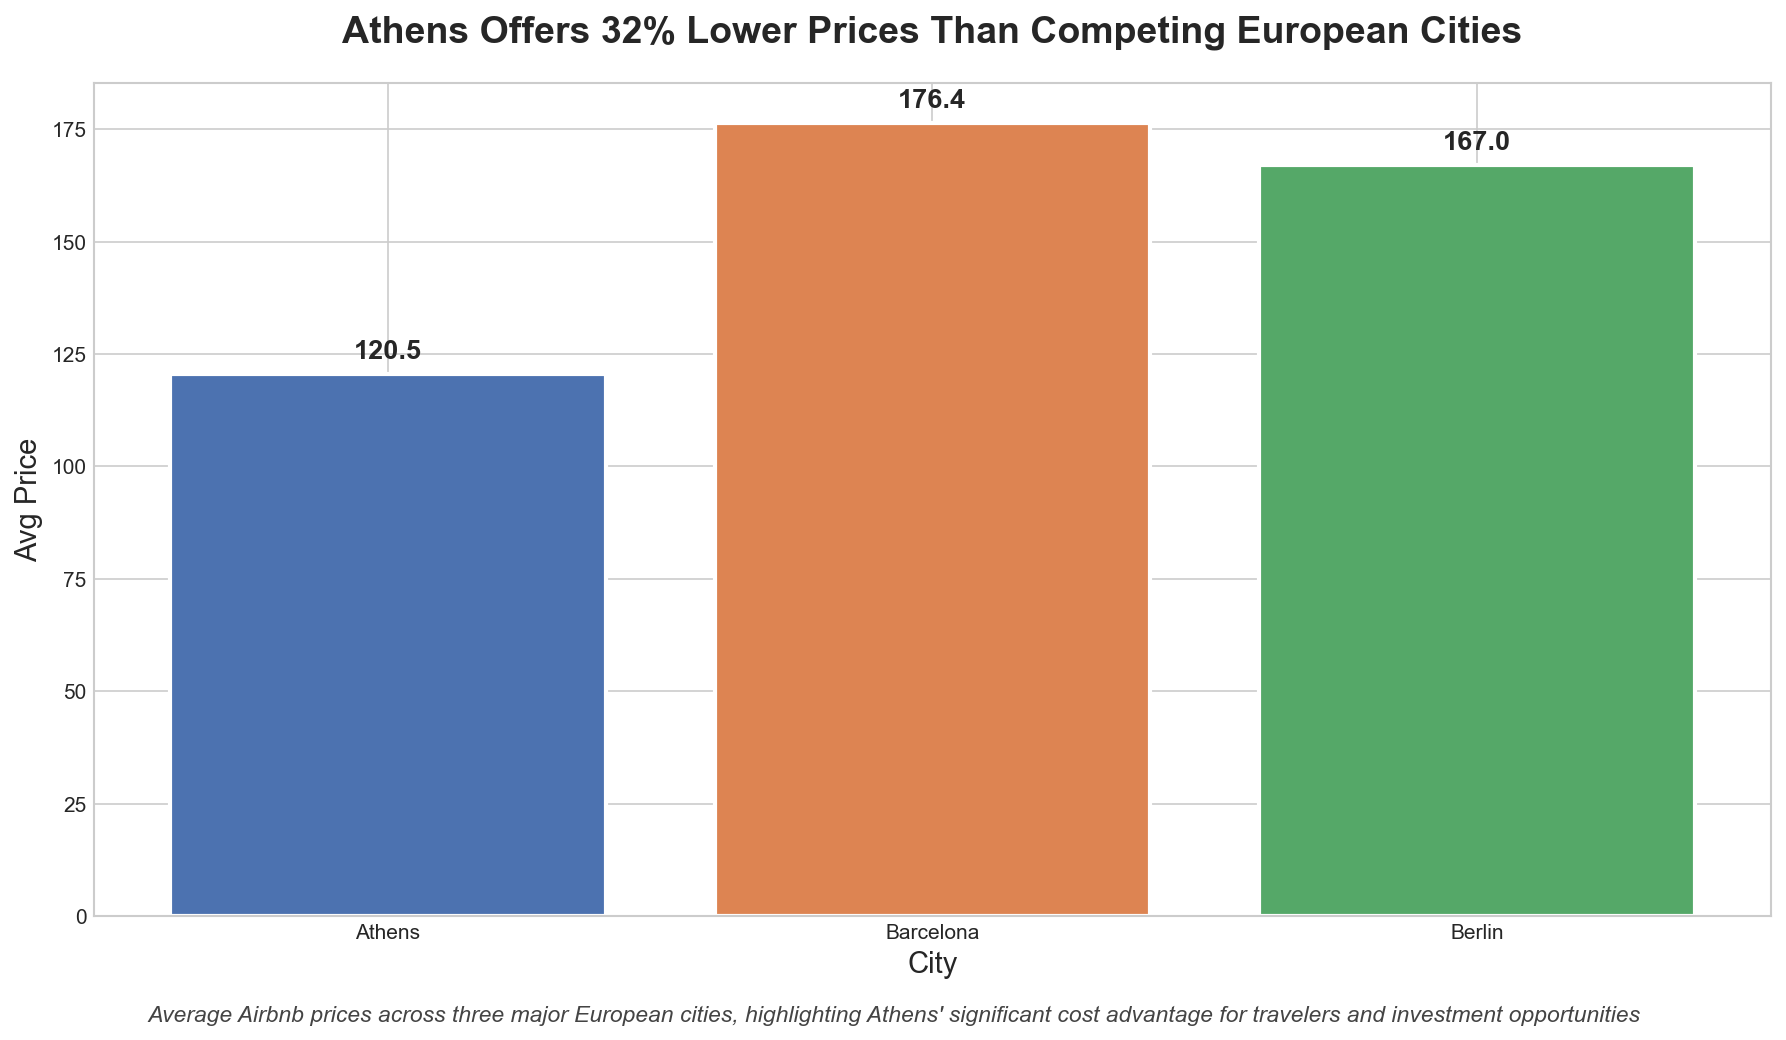


📂 CITYS ANALYZED: ['Athens', 'Barcelona', 'Berlin']
   • Athens: 14,969 records
   • Barcelona: 18,642 records
   • Berlin: 13,713 records

🧹 CLEANING ACTIONS (24 total)
   ✓ Athens: Removed 156 outlier rows in 'id'
   ✓ Athens: Removed 155 outlier rows in 'host_id'
   ✓ Athens: Filled 'neighbourhood_group' with 0
   ✓ Athens: Removed 153 outlier rows in 'latitude'
   ✓ Athens: Removed 151 outlier rows in 'longitude'
   ✓ Athens: Filled 'price' with median (79.00)
   ✓ Athens: Filled 'last_review' with most common value
   ✓ Athens: Filled 'reviews_per_month' with 0
   ... and 16 more

👤 YOUR PREFERENCES (applied to ALL citys)
   • id: Remove outlier rows
   • host_id: Remove outlier rows
   • neighbourhood_group: Fill with 0
   • latitude: Remove outlier rows
   • longitude: Remove outlier rows
   • price: Fill with median
   • minimum_nights: Keep all values
   • number_of_reviews: Keep all values
   • last_review: Fill with most common value
   • reviews_per_month: Fill with 0
   •

In [29]:
# 🚀 Resume the agent with your preferences!

print("\n" + "═" * 70)
print("▶️  RESUMING AGENT WITH YOUR PREFERENCES")
print("═" * 70)

human_response = Command(resume=my_preferences)
final_result = agent.invoke(human_response, config)

print("\n🎉 Workflow complete!")

---
## 🔬 Inspect Results

In [30]:
# View detailed results
if final_result.get("analysis_results"):
    print("📊 ANALYSIS RESULTS\n")

    # Entity stats
    print("Entity-Level Statistics:")
    stats_df = pd.DataFrame(final_result["analysis_results"]["entity_stats"])
    display(stats_df.T)

    # Group breakdown (if any)
    if final_result["analysis_results"].get("group_breakdown"):
        print("\nGroup Breakdown:")
        group_df = pd.DataFrame(final_result["analysis_results"]["group_breakdown"])
        display(group_df)
    
    print(f"\nTotal records: {final_result['analysis_results'].get('total_records', 'N/A'):,}")

📊 ANALYSIS RESULTS

Entity-Level Statistics:


,Athens,Barcelona,Berlin
records,1.496900e+04,1.864200e+04,1.371300e+04
avg_id,7.558455e+17,6.027804e+17,5.024214e+17
median_id,9.301704e+17,6.795951e+17,5.103358e+07
avg_host_id,2.791468e+08,2.047238e+08,1.838621e+08
median_host_id,2.235075e+08,1.338027e+08,8.367629e+07
avg_latitude,3.798000e+01,4.139000e+01,5.251000e+01
median_latitude,3.798000e+01,4.139000e+01,5.251000e+01
avg_longitude,2.373000e+01,2.170000e+00,1.340000e+01
median_longitude,2.373000e+01,2.170000e+00,1.341000e+01
avg_price,1.205000e+02,1.764000e+02,1.670200e+02



Group Breakdown:


,1Ο ΝΕΚΡΟΤΑΦΕΙΟ,Adlershof,Albrechtstr.,Alexanderplatz,Allende-Viertel,Alt Treptow,Alt-Hohenschönhausen Nord,Alt-Hohenschönhausen Süd,Alt-Lichtenberg,Altglienicke,...,ΠΑΤΗΣΙΑ,ΠΕΔΙΟ ΑΡΕΩΣ,ΠΕΤΡΑΛΩΝΑ,ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ,ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,ΠΟΛΥΓΩΝΟ,ΡΗΓΙΛΛΗΣ,ΣΕΠΟΛΙΑ,ΣΤΑΔΙΟ,ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ
Athens,45,0,0,0,0,0,0,0,0,0,...,145,113,429,172,572,26,6,63,283,84
Barcelona,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Berlin,0,40,78,926,4,107,12,23,59,24,...,0,0,0,0,0,0,0,0,0,0



Total records: 47,324


In [31]:
# Preview cleaned data for the first entity
if final_result.get("entity_datasets"):
    entity = list(final_result["entity_datasets"].keys())[0]
    entity_data = final_result["entity_datasets"][entity]

    if entity_data.get("cleaned_data"):
        cleaned_df = pd.read_csv(pd.io.common.StringIO(entity_data["cleaned_data"]))
        print(f"📊 Cleaned Data Preview ({entity}):")
        display(cleaned_df.head(10))

        print(f"\n📈 Quick Stats:")
        print(f"   Rows: {len(cleaned_df):,}")
        for col in cleaned_df.select_dtypes(include="number").columns[:3]:
            print(f"   Avg {col}: {cleaned_df[col].mean():.2f}")

📊 Cleaned Data Preview (Athens):


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,city
0,27262,"AQA-No7, Great mattress, high speed internet",37177,Emmanouil,0.0,ΑΜΠΕΛΟΚΗΠΟΙ,37.98924,23.76500,Entire home/apt,79.0,1,29,2024-11-18,0.18,1,0,4,00002433111,Athens
1,33945,Spacious Cosy aprtm very close to Metro!,146553,Katerina,0.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.00673,23.72775,Entire home/apt,45.0,4,89,2025-09-06,0.49,1,269,16,00000874421,Athens
2,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,Stathis,0.0,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.97670,23.73064,Entire home/apt,160.0,2,142,2025-07-22,0.83,3,72,2,00000876484,Athens
3,60394,Cosy apartment! Great central Athens location!,290864,Dimitra,0.0,ΣΤΑΔΙΟ,37.96738,23.74038,Entire home/apt,50.0,6,37,2025-07-31,0.29,1,54,5,00000508830,Athens
4,134340,Neo Pagrati Athens Apartment,659406,Konstantinos,0.0,ΠΑΓΚΡΑΤΙ,37.96405,23.74968,Entire home/apt,79.0,3,61,2025-07-22,0.36,1,0,6,00002821300,Athens
5,154243,LUSCIOUS ROOF GARDEN IN THE CENTER!,741851,Yagos,0.0,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,37.98574,23.73323,Entire home/apt,70.0,2,225,2025-09-07,1.30,1,347,14,00000532953,Athens
6,155654,"Acropolis Cosy Apartment, Koukaki",712602,Nikos,0.0,ΑΚΡΟΠΟΛΗ,37.96828,23.72906,Entire home/apt,57.0,2,65,2023-10-14,0.47,2,0,0,00000429243,Athens
7,270611,An Oasis in the Heart of Athens,1416651,Paul,0.0,ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,37.98586,23.72432,Entire home/apt,79.0,3,46,2023-06-25,0.29,1,364,0,00000040022,Athens
8,306234,Athens AVATON - Parthenon Suite,1574876,Agis,0.0,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.97851,23.72479,Entire home/apt,400.0,2,728,2025-09-21,4.62,4,276,49,00001465616,Athens
9,308157,#AH32 Grey studio,1585338,Flavia,0.0,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,37.98729,23.74311,Entire home/apt,54.0,5,2,2016-04-05,0.02,19,210,0,00003111357,Athens



📈 Quick Stats:
   Rows: 14,969
   Avg id: 755845519966847488.00
   Avg host_id: 279146823.52
   Avg neighbourhood_group: 0.00


---
## 🔁 Reuse Preferences for New Data

**This is the real power!** Once you've set preferences, you can add more cities or process updated data with the same cleaning rules.

In [32]:
# 💾 Save your preferences for future use
if final_result.get("user_preferences"):
    SESSION_NAME = DATASET_CONFIG.get("session_name", "analysis")
    prefs_file = f"{SESSION_NAME}_cleaning_preferences.json"

    with open(prefs_file, "w") as f:
        json.dump({
            "preferences": final_result["user_preferences"],
            "entity_column": DATASET_CONFIG["entity_column"],
            "created_from_entities": list(final_result["entity_datasets"].keys()),
            "thread_id": thread_id
        }, f, indent=2)

    print(f"💾 Preferences saved to: {prefs_file}")
    print("\n📋 Your saved preferences:")
    for pref in final_result["user_preferences"]:
        print(f"   • {pref['column']}: {pref['choice']}")

    print("\n💡 You can now load these and apply to new entities!")

# 💾 Save cleaned datasets to disk
if final_result.get("entity_datasets"):
    SESSION_NAME = DATASET_CONFIG.get("session_name", "analysis")
    output_dir = Path(f"{SESSION_NAME}_cleaned")
    output_dir.mkdir(exist_ok=True)

    for entity_name, entity_data in final_result["entity_datasets"].items():
        if entity_data.get("cleaned_data"):
            out_path = output_dir / f"{entity_name}_cleaned.csv"
            pd.read_csv(pd.io.common.StringIO(entity_data["cleaned_data"])).to_csv(out_path, index=False)
            print(f"💾 Saved: {out_path}  ({entity_data['row_count']:,} rows)")

💾 Preferences saved to: analysis_cleaning_preferences.json

📋 Your saved preferences:
   • id: Remove outlier rows
   • host_id: Remove outlier rows
   • neighbourhood_group: Fill with 0
   • latitude: Remove outlier rows
   • longitude: Remove outlier rows
   • price: Fill with median
   • minimum_nights: Keep all values
   • number_of_reviews: Keep all values
   • last_review: Fill with most common value
   • reviews_per_month: Fill with 0
   • number_of_reviews_ltm: Keep all values

💡 You can now load these and apply to new entities!
💾 Saved: analysis_cleaned/Athens_cleaned.csv  (14,969 rows)
💾 Saved: analysis_cleaned/Barcelona_cleaned.csv  (18,642 rows)
💾 Saved: analysis_cleaned/Berlin_cleaned.csv  (13,713 rows)


---
## 📚 Key Takeaways

### What You Built

1. **Multi-Dataset Processing** — Load and process 4 cities in one workflow
2. **Shared Preferences** — Ask once, apply to all (impossible in Cursor!)
3. **Autonomous Analysis** — LLM decides what analytics to generate
4. **Autonomous Visualization** — LLM decides the most impactful chart for your audience
5. **Persistent State** — Resume anytime, even after kernel restart

### The Workflow

```
Load 4 Cities → Detect Issues → Ask YOUR Preferences → Clean ALL → LLM Decides Task → Analyze → LLM Picks Viz → Create Chart → Report
```

### Why This Matters

| Manual Approach | Your Agent |
|----------------|-------------|
| Clean each city separately | One preference, all cities |
| Decide analysis yourself | LLM suggests best analysis |
| Create charts manually | LLM picks the most impactful viz |
| Repeat for new data | Saved preferences, instant apply |
| No audit trail | Full traceability |

---

<div style="background: linear-gradient(135deg, #FF5A5F 0%, #00A699 100%); padding: 20px; border-radius: 10px; color: white; text-align: center;">
    <h3 style="color: white;">🎉 Congratulations!</h3>
    <p>You built a <strong>multi-city, preference-aware, autonomous analysis agent</strong> for Airbnb data!</p>
    <p>Your agent asks for preferences ONCE, applies them to ALL cities, lets the LLM decide what to analyze, AND automatically creates the most impactful visualization for your presentation!</p>
</div>